In [1]:
import fastf1
import pandas as pd
import matplotlib.pyplot as plt

fastf1.Cache.enable_cache('../cache')

session = fastf1.get_session(2026, 'Silverstone', 'R')
session.load(telemetry=False, messages=False)

laps = session.laps
print(laps.shape)

core           INFO 	Loading data for British Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 22 drivers: ['16', '63', '44', '1', '6', '30', '41', '5', '43', '10', '81', '87', '31', '11', '12', '77', '55', '14', '18', '3', '23', '27']


(1113, 31)


In [2]:
laps.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:57:20.252000,NOR,1,0 days 00:01:40.454000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:39.496000,...,True,McLaren,0 days 00:55:39.562000,NaT,12,7.0,None,,False,False
1,0 days 00:58:55.088000,NOR,1,0 days 00:01:34.836000,2.0,1.0,NaT,NaT,0 days 00:00:30.170000,0 days 00:00:38.718000,...,True,McLaren,0 days 00:57:20.252000,NaT,12,7.0,None,,False,True
2,0 days 01:00:30.329000,NOR,1,0 days 00:01:35.241000,3.0,1.0,NaT,NaT,0 days 00:00:30.061000,0 days 00:00:38.936000,...,True,McLaren,0 days 00:58:55.088000,NaT,1,7.0,None,,False,True
3,0 days 01:02:05.445000,NOR,1,0 days 00:01:35.116000,4.0,1.0,NaT,NaT,0 days 00:00:29.899000,0 days 00:00:39.002000,...,True,McLaren,0 days 01:00:30.329000,NaT,1,7.0,None,,False,True
4,0 days 01:03:40.599000,NOR,1,0 days 00:01:35.154000,5.0,1.0,NaT,NaT,0 days 00:00:29.884000,0 days 00:00:38.996000,...,True,McLaren,0 days 01:02:05.445000,NaT,1,7.0,None,,False,True


In [3]:
laps['Driver']

0       NOR
1       NOR
2       NOR
3       NOR
4       NOR
       ... 
1108    BEA
1109    BEA
1110    BEA
1111    BEA
1112    BEA
Name: Driver, Length: 1113, dtype: object

In [4]:
laps['Team'].value_counts()

Team
McLaren            104
Alpine             104
Cadillac           104
Mercedes           104
Ferrari            104
Racing Bulls       104
Haas F1 Team       104
Aston Martin       102
Red Bull Racing     99
Williams            95
Audi                89
Name: count, dtype: int64

In [5]:
laps['Team'].value_counts(dropna=False)

Team
McLaren            104
Alpine             104
Cadillac           104
Mercedes           104
Ferrari            104
Racing Bulls       104
Haas F1 Team       104
Aston Martin       102
Red Bull Racing     99
Williams            95
Audi                89
Name: count, dtype: int64

In [6]:
laps['LapNumber'].describe()

count    1113.000000
mean       25.925427
std        14.801225
min         1.000000
25%        13.000000
50%        26.000000
75%        38.000000
max        52.000000
Name: LapNumber, dtype: float64

In [7]:
laps['Position'].isna().sum()

np.int64(2)

In [8]:
laps['TyreLife'].describe

<bound method NDFrame.describe of 0       1.0
1       2.0
2       3.0
3       4.0
4       5.0
       ... 
1108    4.0
1109    5.0
1110    6.0
1111    7.0
1112    8.0
Name: TyreLife, Length: 1113, dtype: float64>

In [9]:
laps['Compound'].value_counts(dropna=False)

Compound
MEDIUM    551
HARD      457
SOFT      105
Name: count, dtype: int64

In [10]:
laps['Compound'].value_counts(dropna=False)

Compound
MEDIUM    551
HARD      457
SOFT      105
Name: count, dtype: int64

In [11]:
laps['TyreLife'].describe

<bound method NDFrame.describe of 0       1.0
1       2.0
2       3.0
3       4.0
4       5.0
       ... 
1108    4.0
1109    5.0
1110    6.0
1111    7.0
1112    8.0
Name: TyreLife, Length: 1113, dtype: float64>

In [12]:
laps['Stint'].value_counts(dropna=False)

Stint
1.0    474
2.0    457
3.0    139
4.0     35
5.0      5
6.0      3
Name: count, dtype: int64

In [13]:
laps['TrackStatus'].value_counts(dropna=False)

TrackStatus
1       876
4        97
12       56
167      17
671      16
124      15
126      12
2671      7
16        5
24        5
71        4
1267      3
Name: count, dtype: int64

In [14]:
laps['LapTime'].isna().sum()

np.int64(21)

In [15]:
laps['LapTimeSeconds'] = laps['LapTime'].dt.total_seconds()

driver_laps = laps[laps['Driver'] == 'VER']

print(driver_laps['Stint'].value_counts())




Stint
2.0    21
1.0    17
3.0     9
Name: count, dtype: int64


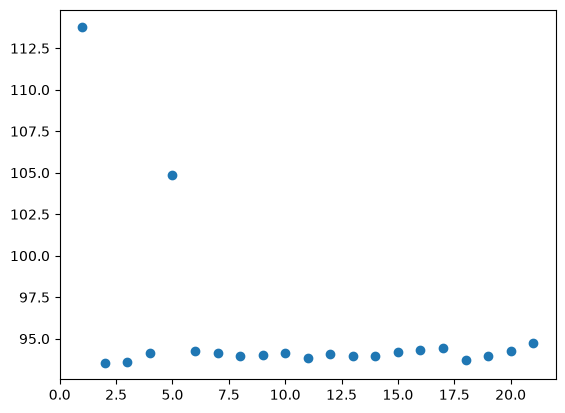

In [16]:
stint_laps = driver_laps[driver_laps['Stint'] == 2]

plt.scatter(stint_laps['TyreLife'], stint_laps['LapTimeSeconds'])

In [17]:
fastf1.set_log_level('WARNING')

schedule = fastf1.get_event_schedule(2026)

for _, event in schedule.iterrows():
    round_number = event['RoundNumber']
    name = event['EventName']

    if round_number == 0:
        continue

    try:
        s = fastf1.get_session(2026, round_number, 'R')
        s.load(telemetry=False, messages=False)
        print(f"OK    {round_number:2d}  {name}  —  {len(s.laps)} laps")
    except Exception as e:
        print(f"FAIL  {round_number:2d}  {name}  —  {e}")

core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 27)


OK     1  Australian Grand Prix  —  1006 laps


core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 1)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 5)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 23)
core        WARNING 	Driver 12 completed the race distance 00:00.022000 before the recorded end of the session.


OK     2  Chinese Grand Prix  —  920 laps
OK     3  Japanese Grand Prix  —  1107 laps


core        WARNING 	Driver 12 completed the race distance 00:00.027000 before the recorded end of the session.


...

FAIL  21  Las Vegas Grand Prix  —  The data you are trying to access has not been loaded yet. See `Session.load`


logger      WARNING 	Failed to load session info data!
core        WARNING 	Failed to load extended driver information!
core        WARNING 	No result data for this session available on Ergast! (This is expected for recent sessions)
core        WARNING 	Failed to load driver list and session results!
logger      WARNING 	Failed to load session status data!
logger      WARNING 	Failed to load total lap count!
logger      WARNING 	Failed to load track status data!
logger      WARNING 	Failed to load timing data!
core        WARNING 	Cannot load lap times for first lap from Ergast. Timing data is not available for this session.
logger      WARNING 	Failed to load weather data!


FAIL  22  Qatar Grand Prix  —  The data you are trying to access has not been loaded yet. See `Session.load`


logger      WARNING 	Failed to load session info data!
core        WARNING 	Failed to load extended driver information!
core        WARNING 	No result data for this session available on Ergast! (This is expected for recent sessions)
core        WARNING 	Failed to load driver list and session results!
logger      WARNING 	Failed to load session status data!
logger      WARNING 	Failed to load total lap count!
logger      WARNING 	Failed to load track status data!
logger      WARNING 	Failed to load timing data!
core        WARNING 	Cannot load lap times for first lap from Ergast. Timing data is not available for this session.
logger      WARNING 	Failed to load weather data!


FAIL  23  Abu Dhabi Grand Prix  —  The data you are trying to access has not been loaded yet. See `Session.load`


In [18]:
all_laps = []

for round_number in range(1, 15):
    session = fastf1.get_session(2026, round_number, 'R')
    session.load(telemetry=False, messages=False)

    race_laps = session.laps.copy()
    race_laps['Race'] = session.event['EventName']
    race_laps['Round'] = round_number

    all_laps.append(race_laps)

laps_all = pd.concat(all_laps, ignore_index=True)
print(laps_all.shape)
   


core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 27)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 1)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 5)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 23)
core        WARNING 	Driver 12 completed the race distance 00:00.022000 before the recorded end of the session.
core        WARNING 	Driver 12 completed the race distance 00:00.027000 before the recorded end of the session.
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 41)
core        WARNING 	Fixed incorrect tyre stint information for 

(16255, 33)


In [19]:
laps_all['Race'].value_counts()

Race
Monaco Grand Prix        1452
Hungarian Grand Prix     1431
Dutch Grand Prix         1368
Austrian Grand Prix      1339
Barcelona Grand Prix     1236
Canadian Grand Prix      1211
British Grand Prix       1113
Japanese Grand Prix      1107
Spanish Grand Prix       1106
Italian Grand Prix       1054
Miami Grand Prix         1040
Australian Grand Prix    1006
Chinese Grand Prix        920
Belgian Grand Prix        872
Name: count, dtype: int64

In [21]:
before = len(laps_all)
clean = laps_all[laps_all['LapTime'].notna()]
print(f"Missing lap time:  {before} -> {len(clean)}  ({before - len(clean)} removed)")

Missing lap time:  16255 -> 15964  (291 removed)


In [22]:
before = len(clean)
clean = clean[clean['Compound'].isin(['SOFT', 'MEDIUM', 'HARD'])]
print(f"Wet compounds: {before} -> {len(clean)} ({before - len(clean)} removed)")


Wet compounds: 15964 -> 15925 (39 removed)


In [23]:
before = len(clean)
clean = clean[clean['PitOutTime'].isna()]
print(f"Out-laps:          {before} -> {len(clean)}  ({before - len(clean)} removed)")

Out-laps:          15925 -> 15426  (499 removed)


In [24]:
before = len(clean)
clean = clean[clean['PitInTime'].isna()]
print(f"In-laps:           {before} -> {len(clean)}  ({before - len(clean)} removed)")

In-laps:           15426 -> 14915  (511 removed)


In [25]:
before = len(clean)
clean = clean[clean['TrackStatus'] == '1']
print(f"Not green flag:    {before} -> {len(clean)}  ({before - len(clean)} removed)")

Not green flag:    14915 -> 13427  (1488 removed)


In [26]:
before = len(clean)
clean = clean[clean['LapNumber'] > 1]
print(f"Lap 1:             {before} -> {len(clean)}  ({before - len(clean)} removed)")

Lap 1:             13427 -> 13262  (165 removed)


In [27]:
before = len(clean)

stint_sizes = clean.groupby(['Race', 'Driver', 'Stint'])['LapNumber'].transform('size')
clean = clean[stint_sizes >= 5]

print(f"Short stints:      {before} -> {len(clean)}  ({before - len(clean)} removed)")

Short stints:      13262 -> 13161  (101 removed)


In [28]:
clean = clean.copy()

In [29]:
FUEL_EFFECT = 0.05   

clean['LapTimeSeconds'] = clean['LapTime'].dt.total_seconds()
clean['LapTimeFuelCorrected'] = clean['LapTimeSeconds'] + FUEL_EFFECT * (clean['LapNumber'] - 1)

In [30]:
print(clean[['LapNumber', 'LapTimeSeconds', 'LapTimeFuelCorrected']].head(10))
print(clean[['LapNumber', 'LapTimeSeconds', 'LapTimeFuelCorrected']].tail(10))

    LapNumber  LapTimeSeconds  LapTimeFuelCorrected
1         2.0          87.344                87.394
2         3.0          86.863                86.963
3         4.0          85.857                86.007
4         5.0          85.573                85.773
5         6.0          85.036                85.286
6         7.0          84.978                85.278
7         8.0          85.299                85.649
8         9.0          85.639                86.039
9        10.0          85.295                85.745
13       14.0          84.233                84.883
       LapNumber  LapTimeSeconds  LapTimeFuelCorrected
16245       47.0          97.927               100.227
16246       48.0          98.139               100.489
16247       49.0          98.635               101.035
16248       50.0          99.441               101.891
16249       51.0         101.079               103.579
16250       52.0          99.224               101.774
16251       53.0         100.479           